A notebook on visualizing and querying results data from wandb; specifically `clirener_(silver)_detailed_results.csv` data.

## Libraries and Data

In [7]:
import pandas as pd
import os
import numpy as np


### Data Aggregate

Aggregate the results into format described below:

model_display_name identifies the model and tag the evaluated entity class. For each metric variant (strict, exact, partial, ent_type), columns report mean (_mean), standard deviation (_std), and number of runs (\_count). overall\_<metric>f1 aggregates F1 across all tags, while <metric>f1, <metric>p, and <metric>r give per-tag F1, precision, and recall. <metric>count columns summarize averaged counts of correct, missed (FN), spurious (FP), and incorrect predictions.

| model_display_name | tag   | overall_strict_f1_mean | strict_f1_mean | strict_p_mean | strict_r_mean | strict_count_correct_mean | strict_count_missed_mean |
|--------------------|-------|------------------------|----------------|---------------|---------------|---------------------------|--------------------------|
| BERT Base          | Asset | 0.49                   | 0.10           | 0.11          | 0.09          | 4.6                       | 10.2                     |


In [13]:
# 1. Load the raw data (the file you just created)
input_file = "clirener_detailed_results.csv" # "clirener_silver_detailed_results.csv"
output_file = "clirener_aggregated_mean_std.csv" # "clirener_silver_aggregated_mean_std.csv"

print(f"Loading {input_file}...")
df = pd.read_csv(input_file)

# 2. Identify the columns to group by
# We want one row per Model + Tag combination
group_cols = ['model_display_name', 'tag']

# 3. Identify numeric columns (metrics)
# We only want to average the numbers, not the strings
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# Ensure we don't try to average columns that might be ID-based if they exist
# (The previous script didn't output IDs, but just to be safe)
cols_to_aggregate = [c for c in numeric_cols if c not in group_cols]

print("Aggregating 5 seeds into Mean and Std Dev...")

# 4. Perform the Aggregation
# This creates a MultiIndex column structure (e.g., strict_f1 -> mean, strict_f1 -> std)
agg_df = df.groupby(group_cols)[cols_to_aggregate].agg(['mean', 'std', 'count'])

# 5. Flatten the columns
# Renames columns to: strict_f1_mean, strict_f1_std, strict_f1_count
agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]

# Reset index so 'model_display_name' and 'tag' become normal columns again
agg_df.reset_index(inplace=True)

# 6. Save to CSV
agg_df.to_csv(output_file, index=False)

print("-" * 30)
print(f"Success! Aggregated data saved to: {output_file}")
print("-" * 30)
print("Preview of the first few rows:")
print(agg_df[['model_display_name', 'tag', 'strict_f1_mean', 'strict_f1_std']].head())

Loading clirener_detailed_results.csv...
Aggregating 5 seeds into Mean and Std Dev...
------------------------------
Success! Aggregated data saved to: clirener_aggregated_mean_std.csv
------------------------------
Preview of the first few rows:
  model_display_name            tag  strict_f1_mean  strict_f1_std
0          BERT Base          Asset        0.101537       0.070023
1          BERT Base      Body Part        0.616570       0.065083
2          BERT Base  Body of Water        0.759951       0.033619
3          BERT Base       Chemical        0.859857       0.027197
4          BERT Base        Disease        0.791887       0.016377


## Architectural Performance Benchmarking and Class-Level NER Analysis

* **Which specific models are the most effective for extracting individual entity types?** (Identifies the top 3 specialized performers for tags like *Location*, *Organization*, etc.)
* **How do different architectural families compare in their ability to recognize domain-specific entities?** (Averages performance across groups like *RoBERTas*, *BERTs*, and *ZS LLMs* to see which technology stack is superior for this task.)
* **Are certain architecture groups better suited for specific entity classes than others?** (Reveals if, for example, *GliNERs* outperform *Encoders* on rare tags or if *LLMs* handle complex context better.)
* **How consistent is model performance across different labeling qualities?** (By toggling between *Gold* and *Silver* data, it allows for a comparison of how architectural rankings hold up against human-annotated vs. automated benchmarks.)
* **What is the overall performance "baseline" for each architectural category in the CliReNER domain?** (Provides a high-level summary of what one can expect from a *DistilRoBERTa* versus a *Full BERT* or *LLM* across the entire dataset.)

In [10]:
# Set this to True for Silver results, False for Gold results
USE_SILVER = False 

if USE_SILVER:
    INPUT_FILE = "clirener_silver_aggregated_mean_std.csv"
    FILE_PREFIX = "silver_"
else:
    INPUT_FILE = "clirener_aggregated_mean_std.csv"
    FILE_PREFIX = "gold_"

# The metric we want to analyze (Metrics: strict_f1_mean, exact_f1_mean, etc.)
TARGET_METRIC = "strict_f1_mean" 

NAME_NORMALIZATION = {
    "GLiNER_Medium": "GLiNER: Medium v2.5",
    "GLiNER_Small": "GLiNER: Small v2.5",
    "INDUS SDE Base": "INDUS SDE v0.2"
}

model_groups_map = {
    "RoBERTas": [
        "RoBERTa Base", "INDUS Base", "INDUS SDE v0.2"
    ],
    "BERTs": [
        "BERT Base", "SciBERT", "CliSciBERT", "CliReBERT"
    ],
    "DistilRoBERTas": [
        "Distil RoBERTa", "EnvironmentalBERT", "ClimateBERT", "SciClimateBERT"
    ],
    "GliNERs": [
        "GLiNER: Small v2.5 ZS", "GLiNER: Small v2.5", 
        "GLiNER: Medium v2.5 ZS", "GLiNER: Medium v2.5"
    ],
    "ZS LLMs": [
        "GPT 5.1 ZS", "GPT 5.2 Pro ZS", 
        "DeepSeek-V3.2 (Non-Thinking) ZS", "DeepSeek-V3.2 (Thinking) ZS",
        "Claude Opus 4.5 ZS", "Claude Sonnet 4.5 ZS", 
        "Gemini 3.0 Pro ZS", "Gemini 2.5 Pro ZS"
    ]
}
# Invert dictionary for mapping
model_to_group = {model: group for group, models in model_groups_map.items() for model in models}


df['model_display_name'] = df['model_display_name'].replace(NAME_NORMALIZATION)

# Check for duplicates after normalization (in case Silver CSV has both names)
# We aggregate by mean just in case there are multiple rows for the "same" model now
df = df.groupby(['model_display_name', 'tag']).mean(numeric_only=True).reset_index()


# =================================================================
# --- 2. Load and Validate ---
# =================================================================
print(f"Loading data from {INPUT_FILE}...")
try:
    df = pd.read_csv(INPUT_FILE)
except FileNotFoundError:
    print(f"Error: {INPUT_FILE} not found. Ensure the file is in the current directory.")
    # Exit or stop execution logic here for notebooks
    raise 

if TARGET_METRIC not in df.columns:
    print(f"Error: Metric '{TARGET_METRIC}' not found in CSV.")
    raise ValueError

# =================================================================
# TASK 1: Find Top 3 Performing Models per Class (Tag)
# =================================================================
print(f"\n{'='*60}")
print(f"TOP 3 MODELS PER CLASS ({'SILVER' if USE_SILVER else 'GOLD'})")
print(f"Metric: {TARGET_METRIC}")
print(f"{'='*60}")

top_3_df = (df.sort_values([TARGET_METRIC], ascending=False)
                .groupby('tag')
                .head(3)
                .sort_values(['tag', TARGET_METRIC], ascending=[True, False]))

unique_tags = top_3_df['tag'].unique()
for tag in unique_tags:
    subset = top_3_df[top_3_df['tag'] == tag]
    print(f"\n--- Class: {tag} ---")
    for i, (_, row) in enumerate(subset.iterrows(), 1):
        print(f"{i}. {row['model_display_name']}: {row[TARGET_METRIC]:.4f}")

# Save Top 3 with specific prefix
top_3_out = f"analysis_{FILE_PREFIX}top_3_per_class.csv"
top_3_df[['tag', 'model_display_name', TARGET_METRIC]].to_csv(top_3_out, index=False)
print(f"\n(Saved detailed list to '{top_3_out}')")

# =================================================================
# TASK 2: Average Performance per Group
# =================================================================
print(f"\n{'='*60}")
print(f"AVERAGE PERFORMANCE BY GROUP ({'SILVER' if USE_SILVER else 'GOLD'})")
print(f"Metric: {TARGET_METRIC}")
print(f"{'='*60}")

# 1. Map models to groups
df['Model_Group'] = df['model_display_name'].map(model_to_group)

# Check for unmapped models
missing = df[df['Model_Group'].isna()]['model_display_name'].unique()
if len(missing) > 0:
    print(f"Warning: The following models were ignored (not in group definition): {missing}")

# 2. Filter out unmapped rows
df_grouped = df.dropna(subset=['Model_Group'])

# 3. Calculate Mean of the Means
group_perf = df_grouped.groupby(['Model_Group', 'tag'])[TARGET_METRIC].mean().reset_index()

# 4. Pivot for readability
pivot_table = group_perf.pivot(index='tag', columns='Model_Group', values=TARGET_METRIC)

# Reorder columns
desired_order = ["RoBERTas", "BERTs", "DistilRoBERTas", "GliNERs", "ZS LLMs"]
existing_order = [col for col in desired_order if col in pivot_table.columns]
pivot_table = pivot_table[existing_order]

print("\nAverage F1 Score per Group per Class:")
print(pivot_table.round(4))

# Save Group Analysis with specific prefix
group_out = f"analysis_{FILE_PREFIX}group_performance.csv"
pivot_table.to_csv(group_out)
print(f"\n(Saved group analysis to '{group_out}')")

Loading data from clirener_aggregated_mean_std.csv...

TOP 3 MODELS PER CLASS (GOLD)
Metric: strict_f1_mean

--- Class: Asset ---
1. Gemini 3.0 Pro ZS: 0.4375
2. GPT 5.2 Pro ZS: 0.4255
3. GLiNER: Small v2.5: 0.4234

--- Class: Body Part ---
1. GLiNER: Medium v2.5: 0.7832
2. Gemini 3.0 Pro ZS: 0.7723
3. GLiNER: Small v2.5: 0.7400

--- Class: Body of Water ---
1. GLiNER: Medium v2.5: 0.9225
2. INDUS Base: 0.8464
3. GLiNER: Small v2.5: 0.8457

--- Class: Chemical ---
1. INDUS SDE v0.2: 0.8828
2. GLiNER: Small v2.5: 0.8821
3. INDUS Base: 0.8805

--- Class: Disease ---
1. Gemini 2.5 Pro ZS: 0.8522
2. Gemini 3.0 Pro ZS: 0.8393
3. GPT 5.1 ZS: 0.8393

--- Class: Ecosystem ---
1. GLiNER: Medium v2.5: 0.8431
2. GLiNER: Small v2.5: 0.7825
3. Gemini 3.0 Pro ZS: 0.7723

--- Class: Energy Source ---
1. GLiNER: Medium v2.5: 0.7838
2. GLiNER: Small v2.5: 0.7791
3. CliSciBERT: 0.6553

--- Class: Field of Study ---
1. DeepSeek-V3.2 (Thinking) ZS: 0.6452
2. GPT 5.1 ZS: 0.6292
3. Claude Sonnet 4.5 ZS: 0.6

## Comparative Evaluation of Architectural Paradigms: Encoders, GLiNERs, and Zero-Shot LLMs

* **Among traditional fine-tuned encoder models (BERT/RoBERTa families), which specific architectures are the top 3 performers for each entity class?** (Identifies the best "small" models for each tag when excluding LLMs and GLiNER.)
* **How do the three major architectural "Super-Groups" (Encoders, GLiNERs, and ZS LLMs) rank against each other for every specific category?** (Determines which technology paradigm wins 1st, 2nd, and 3rd place for each entity type.)
* **Which architectural paradigm achieves the highest average F1 score for a given entity type?** (Identifies the "winning" approach for categories like *Location*, *Organization*, or *Climate Process*.)
* **What is the mean aggregate performance of each broad architectural family (Super-Group) for every tag in the dataset?** (Provides a benchmark of how a typical Encoder performs compared to a typical LLM or GLiNER model per class.)

In [31]:

USE_SILVER = False

if USE_SILVER:
    INPUT_FILE = "clirener_silver_aggregated_mean_std.csv"
    FILE_PREFIX = "silver_"
else:
    INPUT_FILE = "clirener_aggregated_mean_std.csv"
    FILE_PREFIX = "gold_"

TARGET_METRIC = "strict_f1_mean"

# --- Normalization Map (Unifies Silver variants to Gold/Canonical names) ---
NAME_NORMALIZATION = {
    "GLiNER_Medium": "GLiNER: Medium v2.5",
    "GLiNER_Small": "GLiNER: Small v2.5",
    "INDUS SDE Base": "INDUS SDE v0.2"
}

# --- Define Sub-Groups (Using Canonical Names) ---
group_robertas = ["RoBERTa Base", "INDUS Base", "INDUS SDE v0.2"]
group_berts = ["BERT Base", "SciBERT", "CliSciBERT", "CliReBERT"]
group_distils = ["Distil RoBERTa", "EnvironmentalBERT", "ClimateBERT", "SciClimateBERT"] 

group_gliners = [
    "GLiNER: Small v2.5 ZS", "GLiNER: Small v2.5", 
    "GLiNER: Medium v2.5 ZS", "GLiNER: Medium v2.5"
]

group_llms = [
    "GPT 5.1 ZS", "GPT 5.2 Pro ZS", 
    "DeepSeek-V3.2 (Non-Thinking) ZS", "DeepSeek-V3.2 (Thinking) ZS",
    "Claude Opus 4.5 ZS", "Claude Sonnet 4.5 ZS", 
    "Gemini 3.0 Pro ZS", "Gemini 2.5 Pro ZS"
]

# Create the "Encoder Only" list (excluding GLiNERs and LLMs)
encoder_only_list = group_robertas + group_berts + group_distils

# Create "Super Group" Mapping
super_group_map = {}
for m in encoder_only_list: super_group_map[m] = "Encoders"
for m in group_gliners: super_group_map[m] = "GLiNERs"
for m in group_llms: super_group_map[m] = "ZS LLMs"


print(f"Loading data from {INPUT_FILE}...")
try:
    df = pd.read_csv(INPUT_FILE)
except FileNotFoundError:
    print(f"Error: {INPUT_FILE} not found.")

# --- STEP 0: UNIFY NAMES ---
# This turns 'GLiNER_Medium' into 'GLiNER: Medium v2.5' etc.
df['model_display_name'] = df['model_display_name'].replace(NAME_NORMALIZATION)

# =================================================================
# QUESTION 1: Top 3 Encoders per Class (Excluding GLiNER/LLM)
# =================================================================
print(f"\n{'='*70}")
print(f"1. TOP 3 ENCODERS PER CLASS ({'SILVER' if USE_SILVER else 'GOLD'})")
print(f"Groups: RoBERTas, BERTs, DistilRoBERTas")
print(f"{'='*70}")

# Filter Data using the unified names
df_encoders = df[df['model_display_name'].isin(encoder_only_list)].copy()

# Get Top 3
top3_enc = (df_encoders.sort_values([TARGET_METRIC], ascending=False)
                .groupby('tag')
                .head(3)
                .sort_values(['tag', TARGET_METRIC], ascending=[True, False]))

# Display
for tag in top3_enc['tag'].unique():
    print(f"\n--- Class: {tag} ---")
    subset = top3_enc[top3_enc['tag'] == tag]
    for i, (_, row) in enumerate(subset.iterrows(), 1):
        print(f"{i}. {row['model_display_name']} ({row[TARGET_METRIC]:.4f})")
        
top3_out = f"analysis_{FILE_PREFIX}top3_encoders_only.csv"
top3_enc[['tag', 'model_display_name', TARGET_METRIC]].to_csv(top3_out, index=False)


# =================================================================
# QUESTION 2: Super-Group Comparison (Encoders vs GLiNERs vs LLMs)
# =================================================================
print(f"\n\n{'='*70}")
print(f"2. SUPER-GROUP PERFORMANCE ({'SILVER' if USE_SILVER else 'GOLD'})")
print(f"Encoders vs GLiNERs vs ZS LLMs")
print(f"{'='*70}")

# Map models to Super Groups (after name normalization)
df['Super_Group'] = df['model_display_name'].map(super_group_map)

# Drop rows that didn't match any group
df_super = df.dropna(subset=['Super_Group'])

# Calculate Average Performance for the Super Group
super_perf = df_super.groupby(['tag', 'Super_Group'])[TARGET_METRIC].mean().reset_index()

# Sort to find the winner for each class
super_ranked = (super_perf.sort_values([TARGET_METRIC], ascending=False)
                .groupby('tag')
                .head(3) 
                .sort_values(['tag', TARGET_METRIC], ascending=[True, False]))

# Display nicely
current_tag = ""
for _, row in super_ranked.iterrows():
    if row['tag'] != current_tag:
        print(f"\n--- Class: {row['tag']} ---")
        current_tag = row['tag']
        rank_counter = 1
    
    print(f"{rank_counter}. {row['Super_Group']}: {row[TARGET_METRIC]:.4f}")
    rank_counter += 1

# Save Pivot Table
pivot = super_perf.pivot(index='tag', columns='Super_Group', values=TARGET_METRIC)

# Force column order based on what exists
existing_cols = [c for c in ['Encoders', 'GLiNERs', 'ZS LLMs'] if c in pivot.columns]
pivot = pivot[existing_cols]

group_out = f"analysis_{FILE_PREFIX}super_groups_comparison.csv"
pivot.to_csv(group_out)
print(f"\n(Comparison saved to '{group_out}')")



Loading data from clirener_aggregated_mean_std.csv...

1. TOP 3 ENCODERS PER CLASS (GOLD)
Groups: RoBERTas, BERTs, DistilRoBERTas

--- Class: Asset ---
1. RoBERTa Base (0.2164)
2. CliReBERT (0.1985)
3. SciBERT (0.1908)

--- Class: Body Part ---
1. SciBERT (0.7069)
2. CliSciBERT (0.6784)
3. INDUS Base (0.6206)

--- Class: Body of Water ---
1. INDUS Base (0.8464)
2. RoBERTa Base (0.7931)
3. BERT Base (0.7600)

--- Class: Chemical ---
1. INDUS SDE v0.2 (0.8828)
2. INDUS Base (0.8805)
3. ClimateBERT (0.8743)

--- Class: Disease ---
1. INDUS Base (0.8276)
2. BERT Base (0.7919)
3. SciBERT (0.7753)

--- Class: Ecosystem ---
1. RoBERTa Base (0.6388)
2. INDUS Base (0.6184)
3. Distil RoBERTa (0.5920)

--- Class: Energy Source ---
1. CliSciBERT (0.6553)
2. SciBERT (0.6028)
3. RoBERTa Base (0.5969)

--- Class: Field of Study ---
1. RoBERTa Base (0.3326)
2. CliReBERT (0.3272)
3. SciBERT (0.2902)

--- Class: Geographical Feature ---
1. RoBERTa Base (0.3482)
2. BERT Base (0.3329)
3. CliReBERT (0.3032

## Analysis of Task Difficulty, Boundary Precision, and Computational Efficiency

* **Which entity classes are the most challenging to extract correctly across the entire model suite?** (Identifies the "hardest" categories based on the lowest average Strict F1 scores.)
* **For which entity types do models struggle the most with precise span boundaries versus simply identifying the correct category?** (Calculates the "Boundary Gap" to show where models get the entity type right but the start/end offsets wrong.)
* **Which specific models are the most "blurry" or "precise" in their extractions?** (Identifies models with the highest and lowest gaps between Type-matching and Strict-matching F1 scores.)
* **Which architectures provide the best return on investment in terms of performance per parameter?** (Calculates an "Efficiency Ratio" of F1 Score divided by Billion Parameters to find the most computationally cost-effective models.)
* **How does model size correlate with extraction accuracy within the Encoder and GLiNER families?** (Provides the data points needed to map the efficiency frontier, showing which models punch above their weight class.)

In [32]:
USE_SILVER = False  # Toggle to False for Gold results

if USE_SILVER:
    INPUT_FILE = "clirener_silver_aggregated_mean_std.csv"
    FILE_PREFIX = "silver_"
else:
    INPUT_FILE = "clirener_aggregated_mean_std.csv"
    FILE_PREFIX = "gold_"

# --- Normalization Map (Unifies Silver variants to Canonical names) ---
NAME_NORMALIZATION = {
    "GLiNER_Medium": "GLiNER: Medium v2.5",
    "GLiNER_Small": "GLiNER: Small v2.5",
    "INDUS SDE Base": "INDUS SDE v0.2"
}

# --- Parameter Counts (Estimates in Billions) ---
# Note: These keys use the "Canonical" names. 
# Because we normalize the dataframe first, these will match perfectly.

group_robertas = ["RoBERTa Base", "INDUS Base", "INDUS SDE v0.2"]
group_berts = ["BERT Base", "SciBERT", "CliSciBERT", "CliReBERT"]
group_distils = ["Distil RoBERTa", "EnvironmentalBERT", "ClimateBERT", "SciClimateBERT"] 
param_sizes = {
    "Distil RoBERTa": 0.082,
    "EnvironmentalBERT": 0.082,
    "ClimateBERT": 0.082,
    "SciClimateBERT": 0.082,
    
    "BERT Base": 0.11,
    "SciBERT": 0.11,
    "CliSciBERT": 0.11,
    "CliReBERT": 0.11,
    
    "RoBERTa Base": 0.125,
    "INDUS Base": 0.125,
    "INDUS SDE v0.2": 0.125,
    
    "GLiNER: Small v2.5 ZS": 0.15,
    "GLiNER: Small v2.5": 0.15,
    "GLiNER: Medium v2.5 ZS": 0.30,
    "GLiNER: Medium v2.5": 0.30,
}

def main():
    print(f"Loading data from {INPUT_FILE}...")
    try:
        df = pd.read_csv(INPUT_FILE)
    except FileNotFoundError:
        print(f"Error: {INPUT_FILE} not found.")
        return

    # --- STEP 0: UNIFY NAMES ---
    # We do this first so that Boundary Gap and Efficiency calculations 
    # use the same names regardless of source.
    df['model_display_name'] = df['model_display_name'].replace(NAME_NORMALIZATION)

    # =================================================================
    # 1. HARDEST CLASSES (Lowest Average Performance)
    # =================================================================
    print(f"\n{'='*70}")
    print(f"1. HARDEST CLASSES ({'SILVER' if USE_SILVER else 'GOLD'})")
    print(f"Lowest Average Strict F1 across all models")
    print(f"{'='*70}")
    
    # Group by tag and take the mean of means
    hardest_df = df.groupby('tag')['strict_f1_mean'].mean().reset_index()
    hardest_df = hardest_df.sort_values('strict_f1_mean', ascending=True) # Lowest first
    
    for i, (_, row) in enumerate(hardest_df.iterrows(), 1):
        print(f"{i}. {row['tag']}: {row['strict_f1_mean']:.4f}")

    hardest_df.to_csv(f"analysis_{FILE_PREFIX}1_hardest_classes.csv", index=False)

    # =================================================================
    # 2. BOUNDARY ACCURACY (Strict vs Type F1 Gap)
    # =================================================================
    print(f"\n{'='*70}")
    print(f"2. BOUNDARY ACCURACY GAP ({'SILVER' if USE_SILVER else 'GOLD'})")
    print(f"Gap = Entity Type F1 - Strict F1")
    print(f"{'='*70}")

    # Identify the correct column for Type F1 (varies by W&B export setup)
    if 'ent_type_f1_mean' in df.columns:
        type_col = 'ent_type_f1_mean'
    elif 'type_f1_mean' in df.columns:
        type_col = 'type_f1_mean'
    else:
        # Fallback for some versions of the aggregate script
        potential_cols = [c for c in df.columns if 'type_f1' in c and 'mean' in c]
        if potential_cols:
            type_col = potential_cols[0]
        else:
            print("Warning: Type F1 column not found. Skipping Boundary Gap analysis.")
            type_col = None

    if type_col:
        df['boundary_gap'] = df[type_col] - df['strict_f1_mean']
        
        # A. Which Classes have the worst boundary ambiguity?
        class_gap = df.groupby('tag')[['boundary_gap', 'strict_f1_mean', type_col]].mean().reset_index()
        class_gap = class_gap.sort_values('boundary_gap', ascending=False)
        
        print("\n--- Top 5 Classes with Ambiguous Boundaries (Highest Gap) ---")
        print(class_gap[['tag', 'boundary_gap']].head(5).to_string(index=False))

        # B. Which Models struggle most with boundaries?
        model_gap = df.groupby('model_display_name')[['boundary_gap', 'strict_f1_mean', type_col]].mean().reset_index()
        model_gap = model_gap.sort_values('boundary_gap', ascending=False)
        
        print("\n--- Top 5 Models with Boundary Issues (Highest Gap) ---")
        print(model_gap[['model_display_name', 'boundary_gap']].head(5).to_string(index=False))
        
        class_gap.to_csv(f"analysis_{FILE_PREFIX}2_boundary_gap_by_class.csv", index=False)

    # =================================================================
    # 3. EFFICIENCY FRONTIER (Performance vs Size)
    # =================================================================
    print(f"\n{'='*70}")
    print(f"3. EFFICIENCY FRONTIER ({'SILVER' if USE_SILVER else 'GOLD'})")
    print(f"Encoders & GLiNERs Efficiency")
    print(f"{'='*70}")

    # Filter only models where we know the size (using canonical names)
    df_eff = df[df['model_display_name'].isin(param_sizes.keys())].copy()
    
    if df_eff.empty:
        print("No matching models found for efficiency analysis.")
    else:
        # Map parameters
        df_eff['params_billions'] = df_eff['model_display_name'].map(param_sizes)
        
        # Calculate overall mean score per model (average across all tags)
        model_scores = df_eff.groupby(['model_display_name', 'params_billions'])['strict_f1_mean'].mean().reset_index()
        
        # Efficiency Score (F1 per Billion Params)
        model_scores['efficiency_ratio'] = model_scores['strict_f1_mean'] / model_scores['params_billions']
        model_scores = model_scores.sort_values('efficiency_ratio', ascending=False)

        print("\n--- Most Efficient Models (F1 Score / Billion Params) ---")
        print(model_scores[['model_display_name', 'params_billions', 'strict_f1_mean', 'efficiency_ratio']].to_string(index=False))
        
        eff_out = f"analysis_{FILE_PREFIX}3_efficiency_frontier.csv"
        model_scores.to_csv(eff_out, index=False)
        print(f"\n(Efficiency analysis saved to '{eff_out}')")

if __name__ == "__main__":
    main()

Loading data from clirener_aggregated_mean_std.csv...

1. HARDEST CLASSES (GOLD)
Lowest Average Strict F1 across all models
1. System: 0.1879
2. Other: 0.2114
3. Asset: 0.2129
4. Mathematical Expression: 0.2174
5. Natural Phenomenon: 0.2748
6. Policy: 0.2845
7. Physical Artefact: 0.3312
8. Geographical Feature: 0.3377
9. Physical Phenomenon: 0.3388
10. Field of Study: 0.3849
11. Meteorological Phenomenon: 0.4054
12. Intellectual Artefact: 0.4200
13. Natural Disaster: 0.4308
14. Person: 0.4360
15. Satellite: 0.4575
16. Quantity: 0.4984
17. Energy Source: 0.5047
18. Measuring Device: 0.5099
19. Method: 0.5152
20. Location: 0.5294
21. Organization: 0.5319
22. Time Period: 0.5602
23. Body Part: 0.5788
24. Ecosystem: 0.6017
25. Body of Water: 0.6570
26. Organism: 0.7139
27. Disease: 0.7367
28. Chemical: 0.7699

2. BOUNDARY ACCURACY GAP (GOLD)
Gap = Entity Type F1 - Strict F1

--- Top 5 Classes with Ambiguous Boundaries (Highest Gap) ---
                  tag  boundary_gap
         Organizat

## Adding Macro Average F1

In [14]:
# --- Configuration ---
FILES_TO_UPDATE = [
    "clirener_aggregated_mean_std.csv",
    "clirener_silver_aggregated_mean_std.csv"
]

# The metrics we want to create Macro versions for
# We look for these in the columns and calculate the average across tags
METRIC_BASES = ["strict_f1", "exact_f1", "partial_f1", "ent_type_f1", "type_f1"]

def update_macro_metrics(file_path):
    if not os.path.exists(file_path):
        print(f"Skipping: {file_path} (File not found)")
        return

    print(f"Processing: {file_path}")
    df = pd.read_csv(file_path)

    # 1. Identify which metrics are actually in this file
    # (e.g., silver might have 'type_f1_mean' while gold has 'ent_type_f1_mean')
    available_metrics = []
    for base in METRIC_BASES:
        col_name = f"{base}_mean"
        if col_name in df.columns:
            available_metrics.append(col_name)

    if not available_metrics:
        print(f"  [!] No matching metric columns found in {file_path}")
        return

    # 2. Calculate Macro F1 (The mean of the per-tag means)
    # Group by model, take the average of the tag-scores
    macro_df = df.groupby('model_display_name')[available_metrics].mean().reset_index()

    # 3. Rename columns to include the 'overall_' and '_macro' suffix
    # Target format: overall_strict_f1_mean_macro
    rename_dict = {
        m: f"overall_{m}_macro" for m in available_metrics
    }
    macro_df = macro_df.rename(columns=rename_dict)

    # 4. Merge these new macro columns back into the main dataframe
    # Every row for 'RoBERTa' will now have the same 'overall_strict_f1_mean_macro' value
    # First, drop columns if they already exist (to avoid duplicates if re-running)
    cols_to_drop = [c for c in rename_dict.values() if c in df.columns]
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)

    df = df.merge(macro_df, on='model_display_name', how='left')

    # 5. Save the updated file
    df.to_csv(file_path, index=False)
    print(f"  [OK] Added {len(rename_dict)} macro columns to {file_path}")

def main():
    for file in FILES_TO_UPDATE:
        update_macro_metrics(file)
    print("\nAll updates complete.")

if __name__ == "__main__":
    main()

Processing: clirener_aggregated_mean_std.csv
  [OK] Added 4 macro columns to clirener_aggregated_mean_std.csv
Processing: clirener_silver_aggregated_mean_std.csv
  [OK] Added 4 macro columns to clirener_silver_aggregated_mean_std.csv

All updates complete.


## Silver-to-Gold Generalization Gap Analysis

* **How much does model performance fluctuate when moving from silver-labeled (automated) data to gold-labeled (human-annotated) data?** (Quantifies the "optimism bias" of silver results by calculating the absolute and percentage gap in F1 scores.)
* **Which specific entity classes have the most unreliable silver labels?** (Identifies tags where the discrepancy between silver and gold performance is highest, indicating potential noise in the automated labeling process.)
* **Which models are the most robust to label noise?** (Finds models that maintain consistent performance across both datasets versus those that might be "overfitting" to patterns present only in the silver-labeled data.)
* **Is the performance drop-off uniform across models, or do certain architectures (e.g., LLMs vs. Encoders) generalize better to human ground truth?** (Provides the data needed to see if larger models bridge the generalization gap more effectively than smaller ones.)


In [5]:
# =================================================================
# --- 1. Configuration ---
# =================================================================
GOLD_FILE = "clirener_aggregated_mean_std.csv"
SILVER_FILE = "clirener_silver_aggregated_mean_std.csv"

# Choose the metric for gap analysis:
# options: strict_f1_mean, exact_f1_mean, partial_f1_mean, ent_type_f1_mean
TARGET_METRIC = "ent_type_f1_mean" 

# --- Normalization Map (Unifies names between both files) ---
NAME_NORMALIZATION = {
    "GLiNER_Medium": "GLiNER: Medium v2.5",
    "GLiNER_Small": "GLiNER: Small v2.5",
    "INDUS SDE Base": "INDUS SDE v0.2"
}


print(f"Analyzing Generalization Gap: {SILVER_FILE} -> {GOLD_FILE}")
print(f"Metric: {TARGET_METRIC}\n")

try:
    df_gold = pd.read_csv(GOLD_FILE)
    df_silver = pd.read_csv(SILVER_FILE)
except FileNotFoundError as e:
    print(f"Error: {e}")

# --- STEP 0: UNIFY NAMES ---
df_gold['model_display_name'] = df_gold['model_display_name'].replace(NAME_NORMALIZATION)
df_silver['model_display_name'] = df_silver['model_display_name'].replace(NAME_NORMALIZATION)

# Standardize metrics (ensure silver 'type_f1' matches gold 'ent_type_f1' if necessary)
# This logic handles the naming discrepancy between the two projects
if TARGET_METRIC == "ent_type_f1_mean" and "type_f1_mean" in df_silver.columns:
    silver_metric = "type_f1_mean"
elif TARGET_METRIC == "type_f1_mean" and "ent_type_f1_mean" in df_gold.columns:
    # If user asked for type_f1 but gold uses ent_type_f1
    df_gold = df_gold.rename(columns={"ent_type_f1_mean": "type_f1_mean"})
    silver_metric = TARGET_METRIC
else:
    silver_metric = TARGET_METRIC

# --- STEP 1: MERGE DATASETS ---
# Merge on model and tag to compare directly
merged = pd.merge(
    df_gold[['model_display_name', 'tag', TARGET_METRIC]],
    df_silver[['model_display_name', 'tag', silver_metric]],
    on=['model_display_name', 'tag'],
    suffixes=('_gold', '_silver')
)

if merged.empty:
    print("Error: No overlapping models/tags found between Gold and Silver files.")


# --- STEP 2: CALCULATE GAPS ---

# 1. Calculate Absolute Gap
merged['abs_gap'] = merged[f'{silver_metric}_silver'] - merged[f'{TARGET_METRIC}_gold']

# 2. Calculate Percentage Change safely
# We only calculate % if Silver > 0; otherwise, we set it to NaN so it doesn't spoil the mean
merged['percent_change'] = np.where(
    merged[f'{silver_metric}_silver'] > 0, 
    (merged['abs_gap'] / merged[f'{silver_metric}_silver']) * 100, 
    np.nan
)

# Now, when you do .mean(), Pandas will ignore the NaN values 
# (skipna=True is the default), giving you the average of the models that actually had scores.

# =================================================================
# ANALYSIS A: Gap by Entity Class (Which tags are most inconsistent?)
# =================================================================
print(f"{'='*70}")
print(f"GENERALIZATION GAP BY CLASS (Average across all models)")
print(f"{'='*70}")

tag_gap = merged.groupby('tag')[['abs_gap', 'percent_change']].mean().reset_index()
tag_gap = tag_gap.sort_values('abs_gap', ascending=False)

print(tag_gap.to_string(index=False, formatters={'abs_gap': '{:,.4f}'.format, 'percent_change': '{:,.2f}%'.format}))

# =================================================================
# ANALYSIS B: Gap by Model (Which models are most robust?)
# =================================================================
print(f"\n{'='*70}")
print(f"GENERALIZATION GAP BY MODEL (Average across all tags)")
print(f"{'='*70}")

model_gap = merged.groupby('model_display_name')[['abs_gap', 'percent_change']].mean().reset_index()
# Sort by absolute gap: Lowest gap means the model generalizes BEST
model_gap = model_gap.sort_values('abs_gap', ascending=True)

print(model_gap.to_string(index=False, formatters={'abs_gap': '{:,.4f}'.format, 'percent_change': '{:,.2f}%'.format}))

# Save to CSV
output_name = f"analysis_silver_to_gold_{TARGET_METRIC}_gap.csv"
merged.to_csv(output_name, index=False)
print(f"\nDetailed per-tag per-model gap analysis saved to '{output_name}'")

Analyzing Generalization Gap: clirener_silver_aggregated_mean_std.csv -> clirener_aggregated_mean_std.csv
Metric: ent_type_f1_mean

GENERALIZATION GAP BY CLASS (Average across all models)
                      tag abs_gap percent_change
                Ecosystem  0.2640         32.73%
Meteorological Phenomenon  0.2627         38.41%
         Measuring Device  0.1890         24.65%
                   Policy  0.1714         48.28%
                   Person  0.1612         22.49%
                    Asset  0.1561         47.86%
                 Organism  0.1144         12.79%
             Organization  0.1128         13.82%
      Physical Phenomenon  0.1126         18.93%
                Satellite  0.1040         24.02%
              Time Period  0.0869         10.33%
                   System  0.0798         31.70%
                  Disease  0.0795          7.60%
                   Method  0.0777         10.11%
            Body of Water  0.0763          9.63%
                 Location  0

## Model Reliability and Specialist vs. Generalist Analysis

* **Which models act as "consistent workhorses" by providing stable performance across all entity types?** (Identifies models with the lowest variance in scores across the 28+ different tags.)
* **Which architectures are "unstable specialists" that excel at specific tags but fail significantly on others?** (Uses the Coefficient of Variation to find models that have high peak performance but low reliability.)
* **Is there a correlation between high Macro F1 and model stability?** (Determines if the best-performing models are also the most consistent across rare and common classes.)
* **Which models are most "risky" for deployment in diverse environments?** (Identifies models that might have a high micro-average but hidden "blind spots" in specific categories.)

In [19]:
USE_SILVER = False  # Toggle this to False for Gold results

if USE_SILVER:
    INPUT_FILE = "clirener_silver_aggregated_mean_std.csv"
    FILE_PREFIX = "silver_"
else:
    INPUT_FILE = "clirener_aggregated_mean_std.csv"
    FILE_PREFIX = "gold_"

# Use Macro F1 as the anchor for quality, and per-tag mean for stability
TARGET_METRIC = "strict_f1_mean" 
MACRO_COL = f"overall_{TARGET_METRIC}_macro"

# --- Normalization Map ---
NAME_NORMALIZATION = {
    "GLiNER_Medium": "GLiNER: Medium v2.5",
    "GLiNER_Small": "GLiNER: Small v2.5",
    "INDUS SDE Base": "INDUS SDE v0.2"
}

def main():
    print(f"Analyzing Model Stability (Specialist vs. Generalist): {INPUT_FILE}")
    
    try:
        df = pd.read_csv(INPUT_FILE)
    except FileNotFoundError:
        print(f"Error: {INPUT_FILE} not found.")
        return

    # --- STEP 0: UNIFY NAMES ---
    df['model_display_name'] = df['model_display_name'].replace(NAME_NORMALIZATION)

    # =================================================================
    # CALCULATE STABILITY METRICS
    # =================================================================
    # We group by model and look at the distribution of scores across all tags
    stability = df.groupby('model_display_name')[TARGET_METRIC].agg(['mean', 'std', 'min', 'max']).reset_index()
    
    # Coefficient of Variation (CV) = Std Dev / Mean
    # Lower CV = More consistent/stable (Generalist)
    # Higher CV = More specialized/unpredictable (Specialist)
    stability['instability_index_cv'] = (stability['std'] / stability['mean']) * 100
    
    # Range (Max - Min) shows the performance spread
    stability['score_range'] = stability['max'] - stability['min']

    # Rename 'mean' to avoid confusion with the pre-calculated Macro F1 in the CSV
    stability = stability.rename(columns={'mean': 'calculated_macro_f1'})

    # Sort by consistency (lowest instability first)
    stability = stability.sort_values('instability_index_cv', ascending=True)

    print(f"\n{'='*90}")
    print(f"MODEL STABILITY RANKING ({'SILVER' if USE_SILVER else 'GOLD'})")
    print(f"Ranked from most Consistent (Generalist) to most Specialized (Specialist)")
    print(f"{'='*90}")
    
    # Format for printing
    display_cols = ['model_display_name', 'calculated_macro_f1', 'std', 'instability_index_cv', 'score_range']
    print(stability[display_cols].to_string(index=False, formatters={
        'calculated_macro_f1': '{:,.4f}'.format,
        'std': '{:,.4f}'.format,
        'instability_index_cv': '{:,.2f}%'.format,
        'score_range': '{:,.4f}'.format
    }))

    # =================================================================
    # IDENTIFY TOP GENERALISTS AND SPECIALISTS
    # =================================================================
    top_generalist = stability.iloc[0]['model_display_name']
    top_specialist = stability.iloc[-1]['model_display_name']
    
    print(f"\nPROFILES:")
    print(f"-> THE WORKHORSE (Most Consistent): {top_generalist}")
    print(f"   It has the lowest score variance across all entity types.")
    
    print(f"-> THE SPECIALIST (Most Unstable): {top_specialist}")
    print(f"   It excels at some tags but has significant blind spots in others.")

    # Save Analysis
    output_name = f"analysis_{FILE_PREFIX}specialist_vs_generalist.csv"
    stability.to_csv(output_name, index=False)
    print(f"\nStability analysis saved to '{output_name}'")

if __name__ == "__main__":
    main()

Analyzing Model Stability (Specialist vs. Generalist): clirener_aggregated_mean_std.csv

MODEL STABILITY RANKING (GOLD)
Ranked from most Consistent (Generalist) to most Specialized (Specialist)
             model_display_name calculated_macro_f1    std instability_index_cv score_range
            GLiNER: Medium v2.5              0.6312 0.1838               29.12%      0.6164
              Gemini 2.5 Pro ZS              0.5185 0.1512               29.15%      0.7239
              Gemini 3.0 Pro ZS              0.5694 0.1808               31.75%      0.7724
                 GPT 5.2 Pro ZS              0.4431 0.1508               34.03%      0.7003
             Claude Opus 4.5 ZS              0.4916 0.1798               36.56%      0.7529
           Claude Sonnet 4.5 ZS              0.5004 0.1830               36.58%      0.7474
             GLiNER: Small v2.5              0.5792 0.2197               37.92%      0.7520
    DeepSeek-V3.2 (Thinking) ZS              0.4547 0.1737            

## Micro and Macro Overall Ranking

In [15]:
import pandas as pd
import os

# Set pandas to show all rows in the output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# =================================================================
# --- 1. Configuration ---
# =================================================================
FILES = {
    "GOLD": "clirener_aggregated_mean_std.csv",
    "SILVER": "clirener_silver_aggregated_mean_std.csv"
}

NAME_NORMALIZATION = {
    "GLiNER_Medium": "GLiNER: Medium v2.5",
    "GLiNER_Small": "GLiNER: Small v2.5",
    "INDUS SDE Base": "INDUS SDE v0.2"
}

def find_col(df_cols, base, is_macro=False):
    """
    Finds Micro and Macro columns by checking all naming conventions.
    """
    search_terms = [base]
    if base == "type_f1":
        search_terms.append("ent_type_f1")
    
    for term in search_terms:
        if is_macro:
            targets = [f"overall_{term}_mean_macro", f"overall_{term}_macro"]
            for target in targets:
                if target in df_cols: return target
        else:
            variants = [f"overall_{term}", f"overall/{term}", f"overall_{term}_mean", term]
            for v in variants:
                if v in df_cols: return v
    return None

def generate_rankings(dataset_label, file_path):
    if not os.path.exists(file_path):
        print(f"Skipping {dataset_label}: File not found.")
        return
    
    df = pd.read_csv(file_path)
    df['model_display_name'] = df['model_display_name'].replace(NAME_NORMALIZATION)

    # 1. Reduce to one row per model to extract summary metrics
    model_summary = df.groupby('model_display_name').first().reset_index()

    # 2. Extract specifically the Strict F1 Micro and Macro columns
    micro_col = find_col(model_summary.columns, "strict_f1", is_macro=False)
    macro_col = find_col(model_summary.columns, "strict_f1", is_macro=True)

    results = pd.DataFrame({"model_display_name": model_summary["model_display_name"]})
    
    if micro_col:
        results["strict_f1_micro"] = model_summary[micro_col]
    if macro_col:
        results["strict_f1_macro"] = model_summary[macro_col]

    # =================================================================
    # OUTPUT 1: RANKED BY MICRO F1
    # =================================================================
    print(f"\n{'#'*80}")
    print(f"### DATASET: {dataset_label} | RANKED BY STRICT MICRO F1")
    print(f"{'#'*80}")
    
    if "strict_f1_micro" in results.columns:
        micro_ranked = results.sort_values("strict_f1_micro", ascending=False).copy()
        micro_ranked['Rank'] = range(1, len(micro_ranked) + 1)
        print(micro_ranked[['Rank', 'model_display_name', 'strict_f1_micro']].to_string(index=False))
    else:
        print("Micro F1 column not found.")

    # =================================================================
    # OUTPUT 2: RANKED BY MACRO F1
    # =================================================================
    print(f"\n{'#'*80}")
    print(f"### DATASET: {dataset_label} | RANKED BY STRICT MACRO F1")
    print(f"{'#'*80}")
    
    if "strict_f1_macro" in results.columns:
        macro_ranked = results.sort_values("strict_f1_macro", ascending=False).copy()
        macro_ranked['Rank'] = range(1, len(macro_ranked) + 1)
        print(macro_ranked[['Rank', 'model_display_name', 'strict_f1_macro']].to_string(index=False))
    else:
        print("Macro F1 column not found.")
        
    # Save the consolidated scores for this dataset
    results.to_csv(f"consolidated_strict_rankings_{dataset_label.lower()}.csv", index=False)

def main():
    for label, path in FILES.items():
        generate_rankings(label, path)

if __name__ == "__main__":
    main()


################################################################################
### DATASET: GOLD | RANKED BY STRICT MICRO F1
################################################################################
 Rank              model_display_name  strict_f1_micro
    1             GLiNER: Medium v2.5         0.633534
    2              GLiNER: Small v2.5         0.603175
    3               Gemini 3.0 Pro ZS         0.554850
    4                      INDUS Base         0.542367
    5                      CliSciBERT         0.532962
    6                         SciBERT         0.530690
    7                    RoBERTa Base         0.521725
    8               Gemini 2.5 Pro ZS         0.505072
    9                  SciClimateBERT         0.503101
   10                       BERT Base         0.490995
   11                     ClimateBERT         0.488169
   12                  Distil RoBERTa         0.483219
   13            Claude Sonnet 4.5 ZS         0.479459
   14               E

## Type Hardness

In [40]:
USE_SILVER = True  # Toggle to False for Gold results
FILTER_ZS_ON_GOLD = True  # If True, removes LLMs and GLiNER ZS from GOLD analysis

if USE_SILVER:
    INPUT_FILE = "clirener_silver_aggregated_mean_std.csv"
    FILE_PREFIX = "silver_"
else:
    INPUT_FILE = "clirener_aggregated_mean_std.csv"
    FILE_PREFIX = "gold_"

TARGET_METRIC = "strict_f1_mean"

# --- Normalization Map ---
NAME_NORMALIZATION = {
    "GLiNER_Medium": "GLiNER: Medium v2.5",
    "GLiNER_Small": "GLiNER: Small v2.5",
    "INDUS SDE Base": "INDUS SDE v0.2"
}

# --- Zero-Shot Model List (To be filtered if FILTER_ZS_ON_GOLD is True) ---
ZS_MODELS = [
    # GLiNER Zero-Shot
    "GLiNER: Small v2.5 ZS", 
    "GLiNER: Medium v2.5 ZS",
    # LLM Zero-Shot
    "GPT 5.1 ZS", "GPT 5.2 Pro ZS", 
    "DeepSeek-V3.2 (Non-Thinking) ZS", "DeepSeek-V3.2 (Thinking) ZS",
    "Claude Opus 4.5 ZS", "Claude Sonnet 4.5 ZS", 
    "Gemini 3.0 Pro ZS", "Gemini 2.5 Pro ZS"
]

def main():
    print(f"Loading data from {INPUT_FILE}...")
    try:
        df = pd.read_csv(INPUT_FILE)
    except FileNotFoundError:
        print(f"Error: {INPUT_FILE} not found.")
        return

    # --- STEP 0: UNIFY NAMES ---
    df['model_display_name'] = df['model_display_name'].replace(NAME_NORMALIZATION)

    # --- STEP 1: FILTER ZERO-SHOT MODELS (Optional for GOLD) ---
    if not USE_SILVER and FILTER_ZS_ON_GOLD:
        initial_count = df['model_display_name'].nunique()
        df = df[~df['model_display_name'].isin(ZS_MODELS)].copy()
        final_count = df['model_display_name'].nunique()
        
        print(f"\n[FILTER] Removed {initial_count - final_count} Zero-Shot models from analysis.")
        print(f"[FILTER] Remaining models: {df['model_display_name'].unique().tolist()}")

    # =================================================================
    # 2. CALCULATE PERFORMANCE PER ENTITY TYPE
    # =================================================================
    # Aggregate stats across models
    tag_stats = df.groupby('tag')[TARGET_METRIC].agg(['mean', 'std', 'count']).reset_index()
    
    # Rename columns for clarity
    tag_stats.columns = ['Entity Type', 'Avg F1', 'Std Dev', 'Model Count']
    
    # Sort by performance (Descending - Best performance first)
    tag_stats = tag_stats.sort_values('Avg F1', ascending=False)

    print(f"\n{'='*80}")
    subtitle = "EXCLUDING ZERO-SHOT" if (not USE_SILVER and FILTER_ZS_ON_GOLD) else "ALL MODELS"
    print(f"AVERAGE PERFORMANCE PER ENTITY TYPE ({'SILVER' if USE_SILVER else 'GOLD'})")
    print(f"Mode: {subtitle} | Metric: {TARGET_METRIC}")
    print(f"{'='*80}")
    
    # Format for clean display
    display_df = tag_stats.copy()
    display_df['Avg F1'] = display_df['Avg F1'].map('{:.4f}'.format)
    display_df['Std Dev'] = display_df['Std Dev'].map('{:.4f}'.format)
    
    print(display_df.to_string(index=False))

    # =================================================================
    # 3. SAVE RESULTS
    # =================================================================
    filter_suffix = "no_zs_" if (not USE_SILVER and FILTER_ZS_ON_GOLD) else ""
    output_filename = f"analysis_{FILE_PREFIX}{filter_suffix}performance_per_entity_type.csv"
    tag_stats.to_csv(output_filename, index=False)
    print(f"\n(Results saved to '{output_filename}')")

    # =================================================================
    # 4. INSIGHT: Consensus vs. Disagreement
    # =================================================================
    # Remove rows with NaN Std Dev (happens if only 1 model remains for a tag)
    valid_stats = tag_stats.dropna(subset=['Std Dev'])
    
    if not valid_stats.empty:
        disagreement = valid_stats.sort_values('Std Dev', ascending=False).iloc[0]
        consensus = valid_stats.sort_values('Std Dev', ascending=True).iloc[0]

        print(f"\nQuick Insights:")
        print(f"- Highest Model Disagreement: {disagreement['Entity Type']} (Std Dev: {disagreement['Std Dev']:.4f})")
        print(f"- Highest Model Consensus:    {consensus['Entity Type']} (Std Dev: {consensus['Std Dev']:.4f})")
    else:
        print("\nQuick Insights: Insufficient model count to calculate disagreement/consensus.")

if __name__ == "__main__":
    main()

Loading data from clirener_silver_aggregated_mean_std.csv...

AVERAGE PERFORMANCE PER ENTITY TYPE (SILVER)
Mode: ALL MODELS | Metric: strict_f1_mean
              Entity Type Avg F1 Std Dev  Model Count
                 Chemical 0.8497  0.0526           13
                  Disease 0.8310  0.1269           13
                 Organism 0.8211  0.0407           13
                Ecosystem 0.7994  0.0648           13
             Organization 0.7187  0.0984           13
              Time Period 0.7069  0.0296           13
                   Person 0.6989  0.0423           13
            Body of Water 0.6792  0.0613           13
                   Method 0.6504  0.0588           13
                 Location 0.6453  0.0790           13
Meteorological Phenomenon 0.6194  0.0471           13
         Measuring Device 0.6052  0.1007           13
                Body Part 0.6003  0.1776           13
                 Quantity 0.5724  0.0381           13
            Energy Source 0.5500  0.1003 

## Domain Adaptation usefulness

In [29]:
USE_SILVER = True  # Toggle to False for Gold results

if USE_SILVER:
    INPUT_FILE = "clirener_silver_aggregated_mean_std.csv"
    FILE_PREFIX = "silver_"
else:
    INPUT_FILE = "clirener_aggregated_mean_std.csv"
    FILE_PREFIX = "gold_"

# The metric exported by W&B (Strict F1 is the standard for NER)
TARGET_METRIC = "strict_f1_mean" 

# --- Normalization Map ---
NAME_NORMALIZATION = {
    "GLiNER_Medium": "GLiNER: Medium v2.5",
    "GLiNER_Small": "GLiNER: Small v2.5",
    "INDUS SDE Base": "INDUS SDE v0.2"
}

# --- Define Encoder-Only Groups ---
# Logic: We compare General-Purpose vs. Domain-Adapted
model_groups_map = {
    "RoBERTas": [
        "RoBERTa Base", "INDUS Base", "INDUS SDE v0.2"
    ],
    "BERTs": [
        "BERT Base", "SciBERT", "CliSciBERT", "CliReBERT"
    ],
    "DistilRoBERTas": [
        "Distil RoBERTa", "EnvironmentalBERT", "ClimateBERT", "SciClimateBERT"
    ]
}

def main():
    print(f"Loading data from {INPUT_FILE}...")
    try:
        df = pd.read_csv(INPUT_FILE)
    except FileNotFoundError:
        print(f"Error: {INPUT_FILE} not found.")
        return

    # --- STEP 0: UNIFY NAMES ---
    df['model_display_name'] = df['model_display_name'].replace(NAME_NORMALIZATION)

    # =================================================================
    # 1. CALCULATE MICRO & MACRO F1 PER MODEL
    # =================================================================
    # MACRO F1: The average of the F1 scores across all unique tags
    macro_f1 = df.groupby('model_display_name')[TARGET_METRIC].mean().reset_index()
    macro_f1.rename(columns={TARGET_METRIC: 'Macro_F1'}, inplace=True)

    # MICRO F1: In your data, the 'overall_strict_f1' was merged into every row.
    # We just need to take the first (or mean) value found for each model.
    # We look for the most common overall metric columns
    micro_col = None
    for col in ['overall_strict_f1', 'overall_strict_f1_mean', 'overall_f1']:
        if col in df.columns:
            micro_col = col
            break
    
    if micro_col:
        micro_f1 = df.groupby('model_display_name')[micro_col].mean().reset_index()
        micro_f1.rename(columns={micro_col: 'Micro_F1'}, inplace=True)
        # Merge Macro and Micro
        model_stats = pd.merge(macro_f1, micro_f1, on='model_display_name')
    else:
        print("Warning: Micro F1 column not found. Using Macro only.")
        model_stats = macro_f1
        model_stats['Micro_F1'] = 0.0 # Placeholder

    # =================================================================
    # 2. GROUP ANALYSIS & STANDINGS
    # =================================================================
    print(f"\n{'='*80}")
    print(f"DOMAIN ADAPTATION STANDINGS ({'SILVER' if USE_SILVER else 'GOLD'})")
    print(f"{'='*80}")

    all_results = []

    for group_name, model_list in model_groups_map.items():
        print(f"\n>>> GROUP: {group_name}")
        
        # Filter for models in this group
        group_df = model_stats[model_stats['model_display_name'].isin(model_list)].copy()
        group_df['Group'] = group_name
        
        # Sort by Micro F1
        group_df = group_df.sort_values('Micro_F1', ascending=False)
        
        # Display
        print(group_df[['model_display_name', 'Micro_F1', 'Macro_F1']].to_string(index=False))
        all_results.append(group_df)

    # Save Results
    final_df = pd.concat(all_results)
    output_filename = f"analysis_{FILE_PREFIX}domain_adaptation_standings.csv"
    final_df.to_csv(output_filename, index=False)
    print(f"\n(Results saved to '{output_filename}')")

    # =================================================================
    # 3. DOMAIN LIFT INSIGHTS
    # =================================================================
    print(f"\n{'='*30}")
    print("KEY DOMAIN LIFT INSIGHTS")
    print(f"{'='*30}")
    
    # helper for specific comparisons
    def get_score(name):
        res = model_stats[model_stats['model_display_name'] == name]['Micro_F1']
        return res.values[0] if not res.empty else None

    # BERT Comparison
    base_b = get_score("BERT Base")
    clire_b = get_score("CliReBERT")
    if base_b and clire_b:
        print(f"- BERT Lift: CliReBERT improves over BERT Base by {clire_b - base_b:.4f} Micro F1.")

    # RoBERTa Comparison
    base_r = get_score("RoBERTa Base")
    indus_r = get_score("INDUS SDE v0.2")
    if base_r and indus_r:
        print(f"- RoBERTa Lift: INDUS SDE v0.2 improves over RoBERTa Base by {indus_r - base_r:.4f} Micro F1.")

    # Distil Comparison
    base_d = get_score("Distil RoBERTa")
    clim_d = get_score("ClimateBERT")
    if base_d and clim_d:
        print(f"- Distil Lift: ClimateBERT improves over Distil RoBERTa by {clim_d - base_d:.4f} Micro F1.")

if __name__ == "__main__":
    main()

Loading data from clirener_silver_aggregated_mean_std.csv...

DOMAIN ADAPTATION STANDINGS (SILVER)

>>> GROUP: RoBERTas
model_display_name  Micro_F1  Macro_F1
        INDUS Base  0.589885  0.475577
      RoBERTa Base  0.587781  0.516611
    INDUS SDE v0.2  0.554841  0.401349

>>> GROUP: BERTs
model_display_name  Micro_F1  Macro_F1
           SciBERT  0.594461  0.524322
        CliSciBERT  0.585176  0.492508
         BERT Base  0.571983  0.476312
         CliReBERT  0.545416  0.511387

>>> GROUP: DistilRoBERTas
model_display_name  Micro_F1  Macro_F1
    SciClimateBERT  0.573632  0.485652
       ClimateBERT  0.552213  0.468733
    Distil RoBERTa  0.546708  0.489742
 EnvironmentalBERT  0.546111  0.459451

(Results saved to 'analysis_silver_domain_adaptation_standings.csv')

KEY DOMAIN LIFT INSIGHTS
- BERT Lift: CliReBERT improves over BERT Base by -0.0266 Micro F1.
- RoBERTa Lift: INDUS SDE v0.2 improves over RoBERTa Base by -0.0329 Micro F1.
- Distil Lift: ClimateBERT improves over Disti

## Slopegraph for silver-gold micro-macro f1

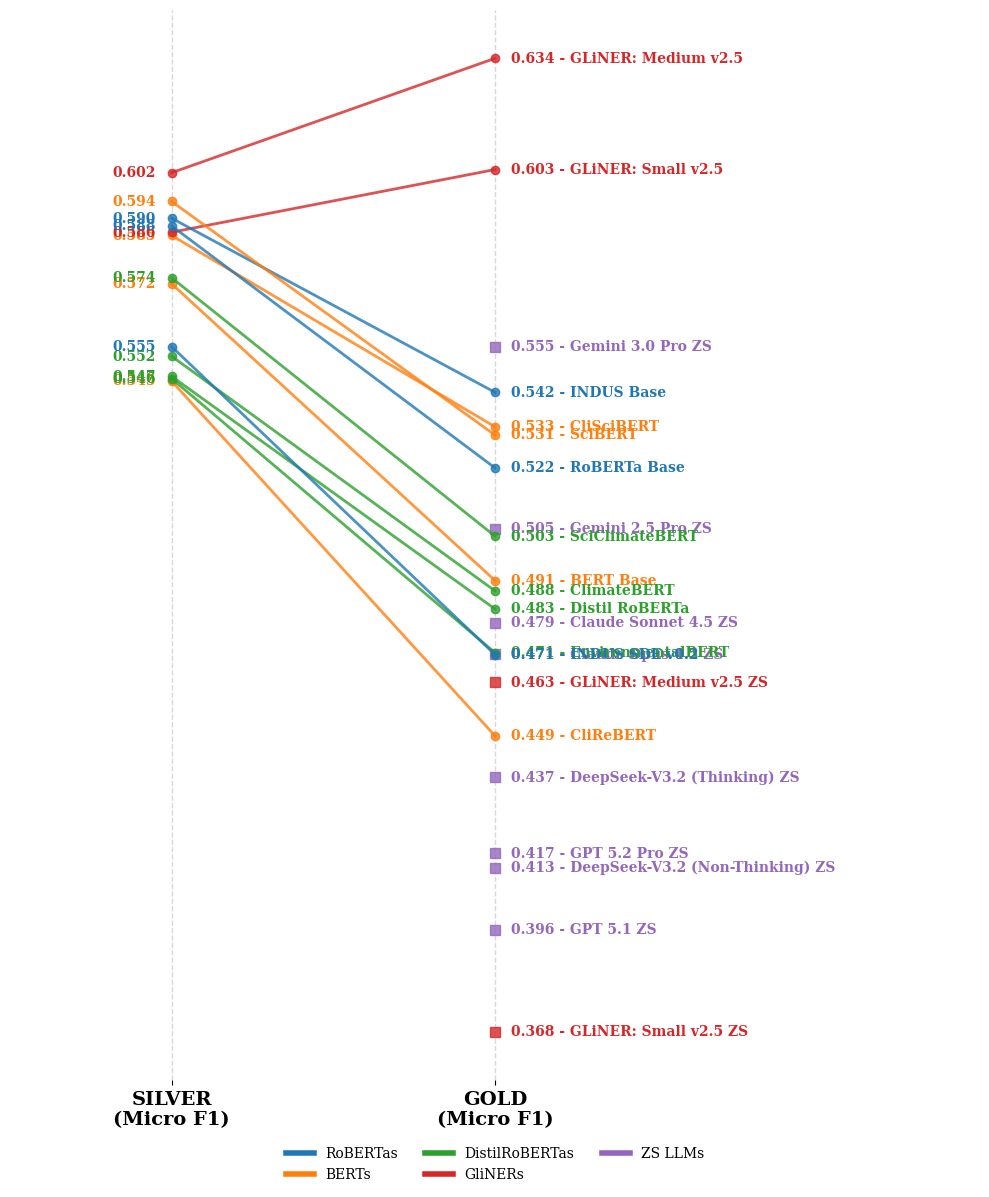

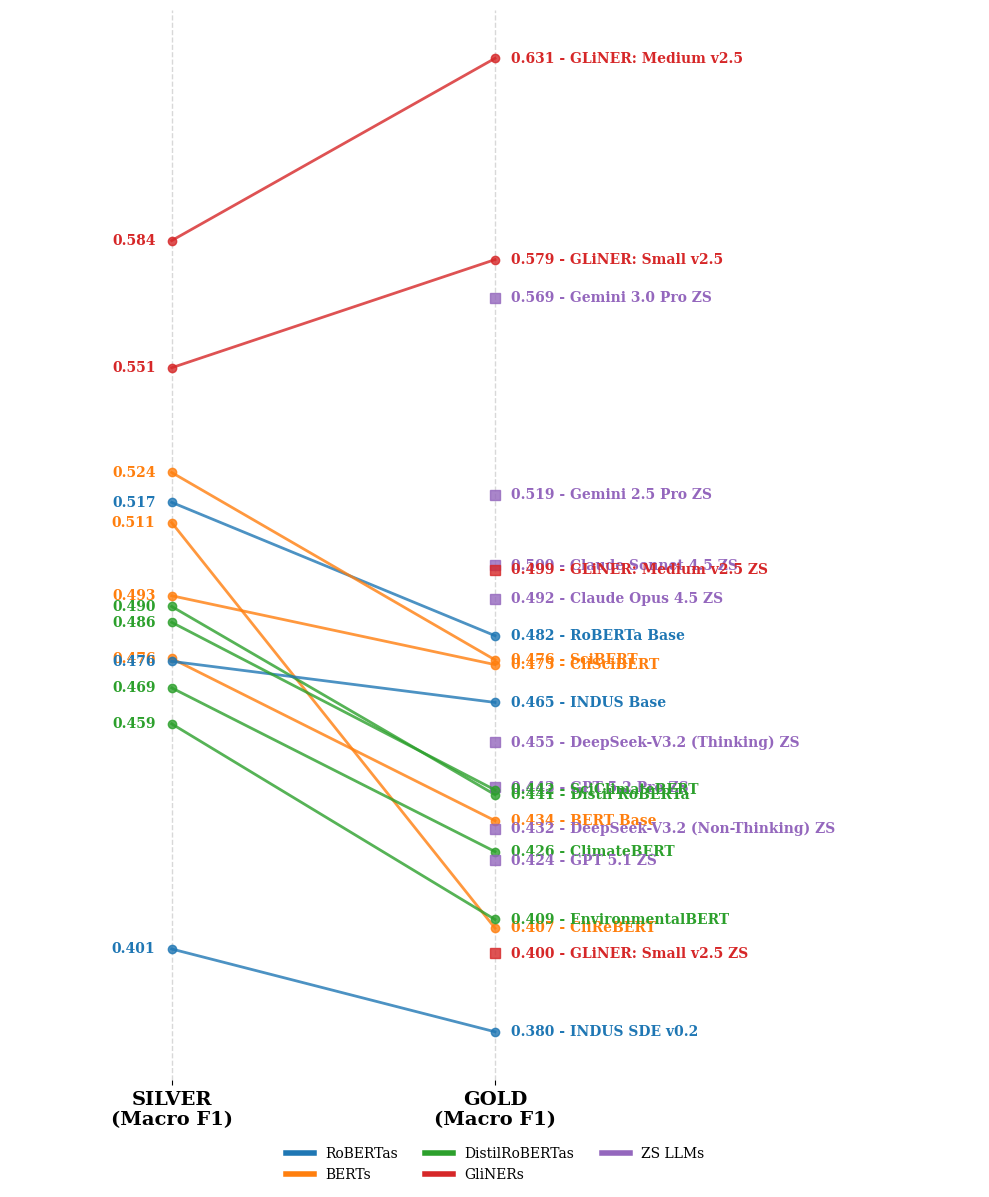

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Configuration & Data Loading ---
GOLD_FILE = "clirener_aggregated_mean_std.csv"
SILVER_FILE = "clirener_silver_aggregated_mean_std.csv"
TARGET_METRIC = "strict_f1_mean"  # Used for Macro
MICRO_METRIC = "overall_strict_f1_mean" # Column name for Micro

NAME_NORMALIZATION = {
    "GLiNER_Medium": "GLiNER: Medium v2.5",
    "GLiNER_Small": "GLiNER: Small v2.5",
    "INDUS SDE Base": "INDUS SDE v0.2"
}

# Colors for groups
GROUP_COLORS = {
    "RoBERTas": "#1f77b4",       # Blue
    "BERTs": "#ff7f0e",          # Orange
    "DistilRoBERTas": "#2ca02c",  # Green
    "GliNERs": "#d62728",        # Red
    "ZS LLMs": "#9467bd"         # Purple
}

model_groups_map = {
    "RoBERTas": ["RoBERTa Base", "INDUS Base", "INDUS SDE v0.2"],
    "BERTs": ["BERT Base", "SciBERT", "CliSciBERT", "CliReBERT"],
    "DistilRoBERTas": ["Distil RoBERTa", "EnvironmentalBERT", "ClimateBERT", "SciClimateBERT"],
    "GliNERs": ["GLiNER: Small v2.5 ZS", "GLiNER: Small v2.5", "GLiNER: Medium v2.5 ZS", "GLiNER: Medium v2.5"],
    "ZS LLMs": ["GPT 5.1 ZS", "GPT 5.2 Pro ZS", "DeepSeek-V3.2 (Non-Thinking) ZS", "DeepSeek-V3.2 (Thinking) ZS", 
                "Claude Opus 4.5 ZS", "Claude Sonnet 4.5 ZS", "Gemini 3.0 Pro ZS", "Gemini 2.5 Pro ZS"]
}
model_to_group = {model: group for group, models in model_groups_map.items() for model in models}

def prepare_data(file_path, label):
    df = pd.read_csv(file_path)
    df['model_display_name'] = df['model_display_name'].replace(NAME_NORMALIZATION)
    
    # Calculate Macro F1 (Average of all tags)
    macro = df.groupby('model_display_name')[TARGET_METRIC].mean().reset_index()
    macro.columns = ['model_display_name', f'Macro_{label}']
    
    # Extract Micro F1 (The overall scalar)
    # We take the mean in case there are multiple seeds, as they share the same overall score
    micro = df.groupby('model_display_name')[MICRO_METRIC].mean().reset_index()
    micro.columns = ['model_display_name', f'Micro_{label}']
    
    return pd.merge(macro, micro, on='model_display_name')

# Load and Merge
df_gold = prepare_data(GOLD_FILE, "Gold")
df_silver = prepare_data(SILVER_FILE, "Silver")
df_combined = pd.merge(df_gold, df_silver, on='model_display_name', how='left')

def plot_slopegraph(metric_type):
    """metric_type: 'Micro' or 'Macro'"""
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["mathtext.fontset"] = "dejavuserif"
    fig, ax = plt.subplots(figsize=(10, 12), dpi=100)
    
    col_silver = f'{metric_type}_Silver'
    col_gold = f'{metric_type}_Gold'
    
    # Set background and spines
    # ax.set_face_color('white')
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Vertical lines for Silver and Gold
    ax.axvline(x=0, color='gray', alpha=0.3, linestyle='--', lw=1)
    ax.axvline(x=1, color='gray', alpha=0.3, linestyle='--', lw=1)

    for i, row in df_combined.iterrows():
        model = row['model_display_name']
        group = model_to_group.get(model, "Unknown")
        color = GROUP_COLORS.get(group, "gray")
        
        y_gold = row[col_gold]
        y_silver = row[col_silver]
        
        # 1. Plot lines for models that exist in both
        if pd.notnull(y_silver):
            # Line
            ax.plot([0, 1], [y_silver, y_gold], color=color, marker='o', markersize=6, lw=2, alpha=0.8)
            # Silver Label (Left)
            ax.text(-0.05, y_silver, f"{y_silver:.3f}", ha='right', va='center', fontsize=10, color=color, fontweight='bold')
        else:
            # 2. Plot standalone points for Gold-only (LLMs)
            ax.plot([1], [y_gold], marker='s', markersize=7, color=color, alpha=0.8)

        # Gold Label (Right)
        label_text = f"{y_gold:.3f} - {model}"
        ax.text(1.05, y_gold, label_text, ha='left', va='center', fontsize=10, color=color, fontweight='bold')

    # Formatting
    ax.set_xlim(-0.5, 2.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'SILVER\n({metric_type} F1)', f'GOLD\n({metric_type} F1)'], fontsize=14, fontweight='bold')
    ax.set_yticks([]) # Hide Y axis numbers as we have text labels
    
    # plt.title(f"Rank Stability: Silver vs. Gold Generalization Gap ({metric_type} F1)", fontsize=16, pad=30)
    
    # Custom Legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], color=c, lw=4, label=g) for g, c in GROUP_COLORS.items()]
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False)
    
    plt.tight_layout()
    plt.show()

# Run for both metrics
plot_slopegraph("Micro")
plot_slopegraph("Macro")

Publication-quality plots saved to: /home/p0l3/RAD/CLIRENER/CliReNER/EXPERIMENTS/VISUALS/PLOTS


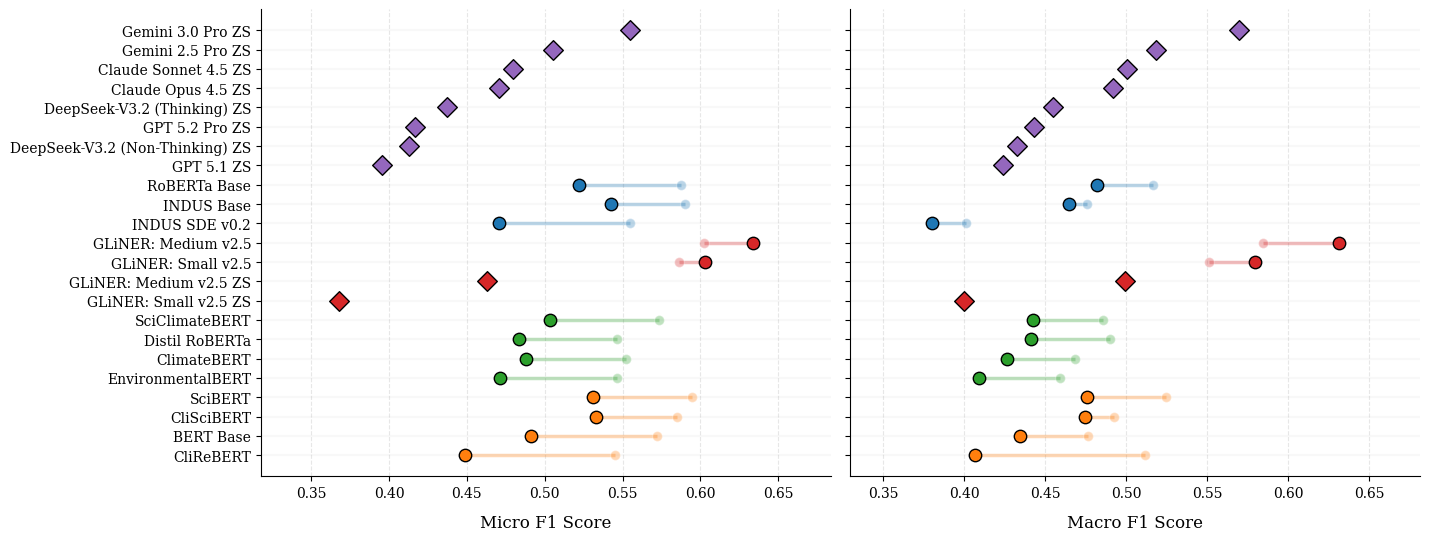

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Configuration (Same as before) ---
GOLD_FILE = "clirener_aggregated_mean_std.csv"
SILVER_FILE = "clirener_silver_aggregated_mean_std.csv"
TARGET_METRIC = "strict_f1_mean"  
MICRO_METRIC = "overall_strict_f1_mean" 

NAME_NORMALIZATION = {
    "GLiNER_Medium": "GLiNER: Medium v2.5",
    "GLiNER_Small": "GLiNER: Small v2.5",
    "INDUS SDE Base": "INDUS SDE v0.2"
}

GROUP_COLORS = {
    "RoBERTa": "#1f77b4", "BERT": "#ff7f0e", "DistilRoBERTa": "#2ca02c",
    "GliNER": "#d62728", "ZS LLM": "#9467bd"
}

model_groups_map = {
    "RoBERTa": ["RoBERTa Base", "INDUS Base", "INDUS SDE v0.2"],
    "BERT": ["BERT Base", "SciBERT", "CliSciBERT", "CliReBERT"],
    "DistilRoBERTa": ["Distil RoBERTa", "EnvironmentalBERT", "ClimateBERT", "SciClimateBERT"],
    "GliNER": ["GLiNER: Small v2.5 ZS", "GLiNER: Small v2.5", "GLiNER: Medium v2.5 ZS", "GLiNER: Medium v2.5"],
    "ZS LLM": ["GPT 5.1 ZS", "GPT 5.2 Pro ZS", "DeepSeek-V3.2 (Non-Thinking) ZS", "DeepSeek-V3.2 (Thinking) ZS", 
                "Claude Opus 4.5 ZS", "Claude Sonnet 4.5 ZS", "Gemini 3.0 Pro ZS", "Gemini 2.5 Pro ZS"]
}
model_to_group = {model: group for group, models in model_groups_map.items() for model in models}

# --- 2. Data Preparation ---
def prepare_data(file_path, label):
    df = pd.read_csv(file_path)
    df['model_display_name'] = df['model_display_name'].replace(NAME_NORMALIZATION)
    macro = df.groupby('model_display_name')[TARGET_METRIC].mean().reset_index()
    macro.columns = ['model_display_name', f'Macro_{label}']
    micro = df.groupby('model_display_name')[MICRO_METRIC].mean().reset_index()
    micro.columns = ['model_display_name', f'Micro_{label}']
    return pd.merge(macro, micro, on='model_display_name')

df_gold = prepare_data(GOLD_FILE, "Gold")
df_silver = prepare_data(SILVER_FILE, "Silver")
df_plot = pd.merge(df_gold, df_silver, on='model_display_name', how='left')

df_plot['Group'] = df_plot['model_display_name'].map(model_to_group)
# Unified sorting (by Micro Gold score) to ensure consistency across subplots
df_plot = df_plot.sort_values(['Group', 'Macro_Gold'], ascending=[True, True]).reset_index(drop=True)

# --- 3. Plotting ---
def plot_stability_subplots():
    # Create figure with 2 subplots sharing Y axis
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    plt.subplots_adjust(wspace=0.05) # Bring subplots closer together

    metrics = [('Micro', ax1), ('Macro', ax2)]
    
    for metric_name, ax in metrics:
        col_gold = f'{metric_name}_Gold'
        col_silver = f'{metric_name}_Silver'
        
        # Add light horizontal guide lines for each model
        for i in range(len(df_plot)):
            ax.axhline(i, color='gray', alpha=0.05, zorder=1)

        for i, row in df_plot.iterrows():
            color = GROUP_COLORS.get(row['Group'], 'gray')
            
            if pd.notnull(row[col_silver]):
                # The Gap Stick
                ax.hlines(y=i, xmin=min(row[col_silver], row[col_gold]), 
                          xmax=max(row[col_silver], row[col_gold]), 
                          color=color, alpha=0.3, linewidth=2.5, zorder=2)
                # Silver (Faded Circle)
                ax.scatter(row[col_silver], i, color=color, alpha=0.3, s=50, edgecolors='white', zorder=3)
                # Gold (Solid Circle)
                ax.scatter(row[col_gold], i, color=color, alpha=1.0, s=80, edgecolors='black', zorder=4)
            else:
                # Zero-Shot (Diamond)
                ax.scatter(row[col_gold], i, color=color, alpha=1.0, s=100, marker='D', edgecolors='black', zorder=4)

        # Labels and Styling
        ax.set_xlabel(f"{metric_name} F1 Score", fontsize=12, labelpad=10)
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        ax.set_axisbelow(True)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        
        # Set shared X limits for fair comparison (optional, but recommended)
        ax.set_xlim(df_plot[[f'{metric_name}_Gold', f'{metric_name}_Silver']].min().min() - 0.05, 
                    df_plot[[f'{metric_name}_Gold', f'{metric_name}_Silver']].max().max() + 0.05)

    # Apply Y-axis labels only to the first subplot
    ax1.set_yticks(range(len(df_plot)))
    ax1.set_yticklabels(df_plot['model_display_name'], fontsize=10)
    
    # # Add Group Labels only on the far right of the second subplot
    # last_group = None
    # for i, row in df_plot.iterrows():
    #     if row['Group'] != last_group:
    #         ax2.text(ax2.get_xlim()[1] + 0.01, i, f" {row['Group']}", va='center', 
    #                 color=GROUP_COLORS.get(row['Group'], 'gray'), fontsize=11)
    #         last_group = row['Group']

    # Final Titles and Legend
    # fig.suptitle("Model Reliability & Generalization Gap: Silver vs. Gold Performance", 
    #              fontsize=16, fontweight='bold', y=0.96)
    
    # Text-based legend/instruction
    # plt.figtext(0.5, 0.91, "● Gold Standard (Human) | ○ Silver Evaluation (Automated) | ♦ Zero-Shot Baseline", 
    #             ha="center", fontsize=11, style='italic', bbox={"facecolor":"white", "alpha":0.5, "pad":5})

    plt.tight_layout(rect=[0, 0.03, 0.9, 0.95]) # Make room for suptitle and group labels
    
    plt.savefig("/home/p0l3/RAD/CLIRENER/CliReNER/PLOTS/stability_lollipop_comparison.pdf", 
                bbox_inches='tight', 
                transparent=False, 
                facecolor='white')

    # 2. PNG (High-resolution raster - 300 DPI is standard for print)
    plt.savefig("/home/p0l3/RAD/CLIRENER/CliReNER/PLOTS/stability_lollipop_comparison.png", 
                dpi=300, 
                bbox_inches='tight', 
                transparent=False, 
                facecolor='white')

    print(f"Publication-quality plots saved to: {os.path.abspath('PLOTS')}")
    
    plt.show()

plot_stability_subplots()